<a href="https://colab.research.google.com/github/gideonadeti/learning-machine-learning/blob/main/Comparative_Machine_Learning_Tutorial_Palmer_Penguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the dataset package
!pip install palmerpenguins

# Import libraries
import pandas as pd
import numpy as np
from palmerpenguins import load_penguins

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, f1_score

# For nice tables
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
penguins = load_penguins()
print("Original shape:", penguins.shape)

# Drop rows with any missing values
penguins_clean = penguins.dropna()
print("After dropping NAs:", penguins_clean.shape)

# Define features and target
X = penguins_clean.drop(columns=['species'])
y = penguins_clean['species']

# Train/test split (stratify to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Original shape: (344, 8)
After dropping NAs: (333, 8)
Training set size: 233
Test set size: 100


In [3]:
# Identify columns by type
categorical_cols = ['island', 'sex']
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
# We'll keep 'year' as an additional numeric feature (could be scaled optionally)
# Add year to numerical cols for scaling if desired:
numerical_cols.append('year')

# Build the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

In [4]:
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Store results
results = []

for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (weighted)': prec,
        'F1 Score (weighted)': f1
    })

    print(f"{name} trained and evaluated.")

Logistic Regression trained and evaluated.
KNN trained and evaluated.
Random Forest trained and evaluated.
Gradient Boosting trained and evaluated.


In [5]:
# Create summary DataFrame
summary_df = pd.DataFrame(results)
summary_df = summary_df.round(4)  # round for readability
summary_df = summary_df.sort_values(by='F1 Score (weighted)', ascending=False)

# Display the table
print("\n=== Model Performance Comparison ===\n")
print(summary_df.to_string(index=False))


=== Model Performance Comparison ===

              Model  Accuracy  Precision (weighted)  F1 Score (weighted)
Logistic Regression      1.00                1.0000               1.0000
      Random Forest      1.00                1.0000               1.0000
  Gradient Boosting      1.00                1.0000               1.0000
                KNN      0.99                0.9902               0.9899


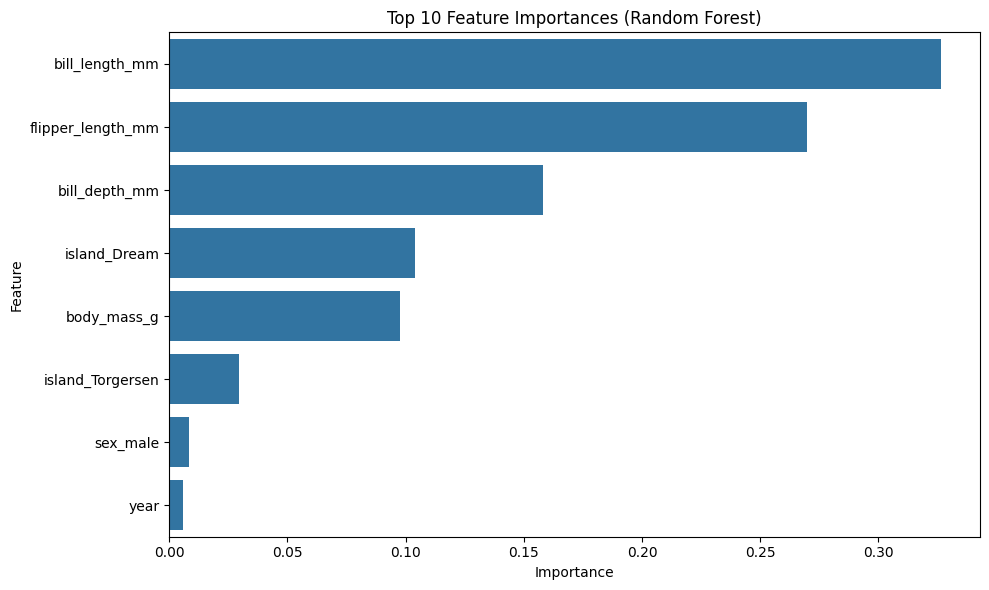

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance for Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_model.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = (numerical_cols +
                 list(rf_model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_cols)))

# Plot importance
importances = rf_model.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()